In this version, I try to import bcs from the gmsh grid

In [2]:
# Cell 1
import gmsh
import meshio
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation, LinearTriInterpolator

plt.rcParams.update({'figure.figsize': (8,6), 'font.size': 12})


In [3]:
import numpy as np
mesh = meshio.read('/Users/straniero/Documents/Dphil/hyperfish/ell_shape_new.msh')
points = mesh.points[:, :2].copy()   # (z,r)
cells = None
for cb in mesh.cells:
    if cb.type == "triangle":
        cells = cb.data.copy()
        break
if cells is None:
    raise RuntimeError("No triangles found in mesh.")

print("Mesh: nodes =", points.shape[0], "triangles =", cells.shape[0])

# --- start from your variables ---
# mesh = meshio.read('/path/to/ell_shape_new.msh')
# points = mesh.points[:, :2].copy()
# cells = ... (triangle block)
n_points = points.shape[0]

# mapping tag -> name if available
tag_to_name = {}
if getattr(mesh, "field_data", None):
    for name, arr in mesh.field_data.items():
        # arr usually [dim, tag] or [tag]
        tag = int(arr[1]) if len(arr) > 1 else int(arr[0])
        tag_to_name[tag] = name

# prepare outputs
is_on_boundary = np.zeros(n_points, dtype=bool)
# For storing physical group names per node (set because node may be in multiple groups)
node_phys_names = [set() for _ in range(n_points)]

# helper to attach a physical tag -> name to a node
def attach_tag_to_node(node_idx, tag):
    if tag is None:
        return
    try:
        tag_int = int(tag)
    except:
        return
    name = tag_to_name.get(tag_int, None)
    if name is not None:
        node_phys_names[node_idx].add(name)
    else:
        # fallback: store tag string if name not available
        node_phys_names[node_idx].add(f"tag_{tag_int}")

# 1) Check for explicit vertex / point cell blocks (0D)
vertex_types = {"vertex", "point", "points"}
found_any = False
for idx, cb in enumerate(mesh.cells):
    ctype = cb.type.lower()
    if ctype in vertex_types:
        found_any = True
        node_indices = cb.data.flatten()
        # corresponding cell_data arrays (if present) are in mesh.cell_data["gmsh:physical"]
        phys_blocks = mesh.cell_data.get("gmsh:physical", None)
        phys_for_block = None
        if phys_blocks is not None and idx < len(phys_blocks):
            phys_for_block = phys_blocks[idx]
        for i, node in enumerate(node_indices):
            is_on_boundary[int(node)] = True
            if phys_for_block is not None:
                tag = phys_for_block[i]
                attach_tag_to_node(int(node), tag)

# 2) Check for explicit 1D boundary elements (lines / segments)
one_d_types = {"line", "line3", "segment", "bar", "edge"}
found_1d = False
for idx, cb in enumerate(mesh.cells):
    ctype = cb.type.lower()
    if ctype in one_d_types:
        found_1d = True
        edges = cb.data  # shape (m, 2) or (m, 3) for higher-order; take first two nodes for topology
        phys_blocks = mesh.cell_data.get("gmsh:physical", None)
        phys_for_block = phys_blocks[idx] if (phys_blocks is not None and idx < len(phys_blocks)) else None
        for j, ent in enumerate(edges):
            # some line element types may be shape (m,2) or (m,3) (with mid nodes); take unique endpoints
            # endpoints = (ent[0], ent[-1]) to be robust
            n0 = int(ent[0]); n1 = int(ent[-1])
            is_on_boundary[n0] = True
            is_on_boundary[n1] = True
            if phys_for_block is not None:
                tag = phys_for_block[j]
                attach_tag_to_node(n0, tag)
                attach_tag_to_node(n1, tag)

# 3) Fallback: if no explicit 1D or vertex blocks, find boundary from triangle connectivity
if not found_any and not found_1d:
    # build edge counts from triangles
    # triangles are in `cells` variable you already extracted (Ntri x 3)
    tri = cells.astype(np.int64)
    # produce canonical ordered edges (min,max) for counting
    e01 = np.vstack([tri[:,0], tri[:,1]]).T
    e12 = np.vstack([tri[:,1], tri[:,2]]).T
    e20 = np.vstack([tri[:,2], tri[:,0]]).T
    all_edges = np.vstack([e01, e12, e20])
    # canonicalize
    mins = np.minimum(all_edges[:,0], all_edges[:,1])
    maxs = np.maximum(all_edges[:,0], all_edges[:,1])
    can_edges = np.vstack([mins, maxs]).T
    # count unique edges
    # view as structured to use numpy unique
    dtype = np.dtype([('a', can_edges.dtype), ('b', can_edges.dtype)])
    can_edges_view = can_edges.view(dtype)
    uniq, counts = np.unique(can_edges_view, return_counts=True)
    # edges that appear once are boundary edges
    boundary_mask = counts == 1
    boundary_edges = np.vstack([uniq['a'][boundary_mask], uniq['b'][boundary_mask]]).T
    # mark nodes on these edges
    for e in boundary_edges:
        n0, n1 = int(e[0]), int(e[1])
        is_on_boundary[n0] = True
        is_on_boundary[n1] = True
    # Note: triangle-only meshes rarely contain gmsh:physical tags for edges in meshio output.
    # If the original .msh had physical groups for boundary lines but meshio didn't write line cells,
    # prefer reading via the gmsh Python API for robust retrieval of physical point groups.

# summary
num_boundary = int(is_on_boundary.sum())
print(f"Total points: {n_points}; boundary points: {num_boundary}")

# optional: create an integer mask (0/1) or indices
boundary_indices = np.nonzero(is_on_boundary)[0]
boundary_mask_int = is_on_boundary.astype(np.uint8)  # 1 for boundary, 0 otherwise

# show a small sample of boundary nodes with any physical names found
sample_show = 20
print("Sample boundary indices (first {}): {}".format(sample_show, boundary_indices[:sample_show].tolist()))
# show names for a few (if any)
named = [(i, sorted(list(node_phys_names[i]))) for i in boundary_indices if node_phys_names[i]]
print("Boundary nodes with physical names (up to 20):", named[:20])

# Now you have:
# - is_on_boundary (bool array)
# - boundary_mask_int (0/1 uint8 array)
# - boundary_indices (list of indices)
# - node_phys_names (list of sets of names for each node)


Mesh: nodes = 2128 triangles = 4076
Total points: 2128; boundary points: 129
Sample boundary indices (first 20): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Boundary nodes with physical names (up to 20): [(np.int64(0), ['domain']), (np.int64(1), ['domain']), (np.int64(2), ['domain']), (np.int64(3), ['domain']), (np.int64(4), ['domain']), (np.int64(5), ['domain']), (np.int64(6), ['domain']), (np.int64(7), ['domain']), (np.int64(8), ['domain']), (np.int64(9), ['domain']), (np.int64(10), ['domain']), (np.int64(11), ['domain']), (np.int64(12), ['domain']), (np.int64(13), ['domain']), (np.int64(14), ['domain']), (np.int64(15), ['domain']), (np.int64(16), ['domain']), (np.int64(17), ['domain']), (np.int64(18), ['domain']), (np.int64(19), ['domain'])]


In [4]:
# Mesh import and boundary-tag parsing moved to Cell 2.
# Use Cell 4 below for the corrected TM H_phi assembly with Robin wall BCs.


In [5]:
# Cell 3 - assemble A and M for the axisymmetric TM H_phi eigenproblem
# PDE for H_phi:
#   d2H/dz2 + d2H/dr2 + (1/r) dH/dr - H/r^2 + k^2 H = 0
# Weak form:
#   int r * grad(H)·grad(v) dA + int (1/r) * H * v dA + int_boundary n_r * H * v ds
#       = k^2 * int r * H * v dA
# where the boundary term applies on PEC walls, and H_phi = 0 only on the axis.
n_nodes = points.shape[0]
n_tris = cells.shape[0]

tri_centroid = np.zeros((n_tris, 2))
tri_area = np.zeros(n_tris)
tri_grads = np.zeros((n_tris, 3, 2))  # grad phi_j = [d/dz, d/dr]

for t_idx, tri in enumerate(cells):
    coords = points[tri]
    tri_centroid[t_idx] = coords.mean(axis=0)
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]
    tri_area[t_idx] = 0.5 * abs((x2 - x1) * (y3 - y1) - (x3 - x1) * (y2 - y1))

    A_loc = np.array([
        [1.0, coords[0, 0], coords[0, 1]],
        [1.0, coords[1, 0], coords[1, 1]],
        [1.0, coords[2, 0], coords[2, 1]],
    ])
    invA = np.linalg.inv(A_loc)
    for local_j in range(3):
        coef = invA[:, local_j]
        tri_grads[t_idx, local_j, 0] = coef[1]
        tri_grads[t_idx, local_j, 1] = coef[2]

# Build boundary edges from triangle connectivity.
edge_to_tri = {}
for t_idx, tri in enumerate(cells):
    local_edges = [(0, 1), (1, 2), (2, 0)]
    for a, b in local_edges:
        i = int(tri[a])
        j = int(tri[b])
        key = tuple(sorted((i, j)))
        edge_to_tri.setdefault(key, []).append(t_idx)
boundary_edges = [edge for edge, owners in edge_to_tri.items() if len(owners) == 1]

rowA = []
colA = []
dataA = []
rowM = []
colM = []
dataM = []

shape_mass = np.array([[2, 1, 1], [1, 2, 1], [1, 1, 2]], dtype=float) / 12.0
edge_mass = np.array([[2, 1], [1, 2]], dtype=float) / 6.0

for t_idx, tri in enumerate(cells):
    area = tri_area[t_idx]
    r_c = max(tri_centroid[t_idx, 1], 1e-12)
    grads = tri_grads[t_idx]

    M_loc = area * r_c * shape_mass
    K_grad = np.zeros((3, 3), dtype=float)
    for i in range(3):
        for j in range(3):
            K_grad[i, j] = area * r_c * float(grads[i] @ grads[j])

    # Extra azimuthal term from the vector Laplacian.
    K_az = area * (1.0 / r_c) * shape_mass
    A_loc = K_grad + K_az

    for i_local, i_global in enumerate(tri):
        for j_local, j_global in enumerate(tri):
            rowA.append(int(i_global)); colA.append(int(j_global)); dataA.append(A_loc[i_local, j_local])
            rowM.append(int(i_global)); colM.append(int(j_global)); dataM.append(M_loc[i_local, j_local])

# Robin term on the metal wall: int n_r * H * v ds.
# Axis edges are excluded and enforced separately with H_phi = 0.
axis_tol = max(1e-10, 0.5 * np.min(np.diff(np.unique(np.round(points[:,1], 12))))) if points.shape[0] > 1 else 1e-10
robin_edges = []
for edge in boundary_edges:
    i, j = edge
    p0 = points[i]
    p1 = points[j]
    if abs(p0[1]) < 1e-9 and abs(p1[1]) < 1e-9:
        continue

    owner = edge_to_tri[edge][0]
    centroid = tri_centroid[owner]
    midpoint = 0.5 * (p0 + p1)
    tangent = p1 - p0
    length = np.linalg.norm(tangent)
    if length <= 0:
        continue

    n1 = np.array([tangent[1], -tangent[0]], dtype=float) / length
    n2 = -n1
    outward_hint = midpoint - centroid
    normal = n1 if np.dot(n1, outward_hint) > np.dot(n2, outward_hint) else n2
    n_r = normal[1]

    r_m = max(midpoint[1], 1e-12)
    A_edge = n_r * length * edge_mass
    globals_edge = [i, j]
    for a_local, a_global in enumerate(globals_edge):
        for b_local, b_global in enumerate(globals_edge):
            rowA.append(int(a_global)); colA.append(int(b_global)); dataA.append(A_edge[a_local, b_local])
    robin_edges.append((i, j, n_r, r_m, length))

A_mat = sp.coo_matrix((dataA, (rowA, colA)), shape=(n_nodes, n_nodes)).tocsr()
M_mat = sp.coo_matrix((dataM, (rowM, colM)), shape=(n_nodes, n_nodes)).tocsr()

print("Assembled matrices: A nnz =", A_mat.nnz, ", M nnz =", M_mat.nnz)
print("Boundary edges =", len(boundary_edges), ", Robin wall edges =", len(robin_edges))


Assembled matrices: A nnz = 14534 , M nnz = 14534
Boundary edges = 178 , Robin wall edges = 128


In [6]:
# Cell 4 - identify Dirichlet nodes
# For the H_phi formulation, only the symmetry axis r = 0 is Dirichlet.
axis_nodes = np.where(np.isclose(points[:,1], 0.0, atol=1e-9))[0]
dirichlet_nodes = axis_nodes
dirichlet_mask = np.zeros(n_nodes, dtype=bool)
dirichlet_mask[dirichlet_nodes] = True
print("Axis/Dirichlet nodes:", dirichlet_nodes.size)

free_idx = np.where(~dirichlet_mask)[0]
n_free = free_idx.size
print("Free DOFs:", n_free)

perm = np.concatenate((free_idx, dirichlet_nodes))
invperm = np.zeros_like(perm)
invperm[perm] = np.arange(n_nodes)

A_perm = A_mat[perm,:][:,perm].tocsr()
M_perm = M_mat[perm,:][:,perm].tocsr()
A_red = A_perm[:n_free, :n_free].tocsr()
M_red = M_perm[:n_free, :n_free].tocsr()


Axis/Dirichlet nodes: 51
Free DOFs: 2077


In [7]:
# Cell 5 - eigen solve
k_eigs = 20  # number of eigenpairs
c = 299792458.0

# Solve the reduced generalized eigenproblem A_red h = lambda M_red h.
# sigma = 0 targets the lowest positive eigenvalues without depending on the driven solve cell.
vals, vecs = spla.eigsh(A_red, k=min(k_eigs, n_free - 2), M=M_red, sigma=0.0, which='LM', tol=1e-9, maxiter=8000)

idx = np.argsort(np.real(vals))
vals = np.maximum(np.real(vals[idx]), 0.0)
vecs = vecs[:, idx]

kvals = np.sqrt(vals)
freqs = kvals * c / (2*np.pi)
print("Frequencies (MHz):", freqs/1e6)


Frequencies (MHz): [1325.32668134 2628.53454277 3037.66172443 3800.3093072  3917.33226059
 4440.85787346 4884.24408524 5394.94376923 5728.51222639 5826.53816359
 6409.50984687 6702.61783831 6896.09005728 7275.22854045 7325.68163102
 7686.82477586 7908.32122388 8233.05529227 8244.94721818 8599.15986557]


In [8]:
# Legacy reconstruction cell intentionally disabled.
# Use the next cell to choose the accelerating mode automatically and reconstruct H_phi.


In [9]:
# Cell 6 - reconstruct full H_phi for a chosen mode index
if 'vecs' not in globals() or 'freqs' not in globals():
    raise RuntimeError('Run Cell 6 first so vecs and freqs are available.')

mode_scores = []
near_axis = np.where(points[:,1] > 1e-9)[0]

for m in range(vecs.shape[1]):
    H_trial = np.zeros(n_nodes, dtype=np.complex128)
    H_trial[free_idx] = vecs[:, m]

    if near_axis.size == 0:
        mode_scores.append(0.0)
        continue

    ez_proxy = np.abs(H_trial[near_axis] / np.maximum(points[near_axis, 1], 1e-12))
    ez_proxy = np.nan_to_num(ez_proxy, nan=0.0, posinf=0.0, neginf=0.0)
    mode_scores.append(float(np.max(ez_proxy)))

mode_scores = np.asarray(mode_scores, dtype=float)
if mode_scores.size == 0:
    raise RuntimeError('No eigenmodes were computed.')

if np.all(mode_scores == 0.0):
    mode_index = 0
else:
    # Ignore the very highest-frequency modes if they dominate only from numerical noise.
    top = min(len(mode_scores), 8)
    candidate_order = np.argsort(mode_scores[:top])[::-1]
    mode_index = int(candidate_order[0])

print('Mode scores:', mode_scores)
print('Chosen mode index:', mode_index, 'frequency (MHz):', freqs[mode_index] / 1e6)


mode_index =0
H_free = vecs[:, mode_index].astype(np.complex128)
H_full = np.zeros(n_nodes, dtype=np.complex128)
H_full[free_idx] = H_free

if np.max(np.abs(H_full)) > 0:
    H_full = H_full / np.max(np.abs(H_full))


Mode scores: [ 1236.15668296  3873.2430284   5650.31809373  8969.20647913
  7862.04173259 10372.90898407 10675.70437158 12025.82105147
 11114.50511177  9773.29352401 16658.21831087 14755.52096949
 18753.07543452 25146.5750987  24086.85620437 23028.32316019
 33886.77779179 30899.96856663 29957.52220678 25639.10071869]
Chosen mode index: 7 frequency (MHz): 5394.943769232915


Grid points: total=90000, inside mesh=59434, outside=30566
Inside field magnitude: min=4.947e+00, max=4.503e+02, mean=3.114e+02
Seeding 254 streamlines (inside mesh).


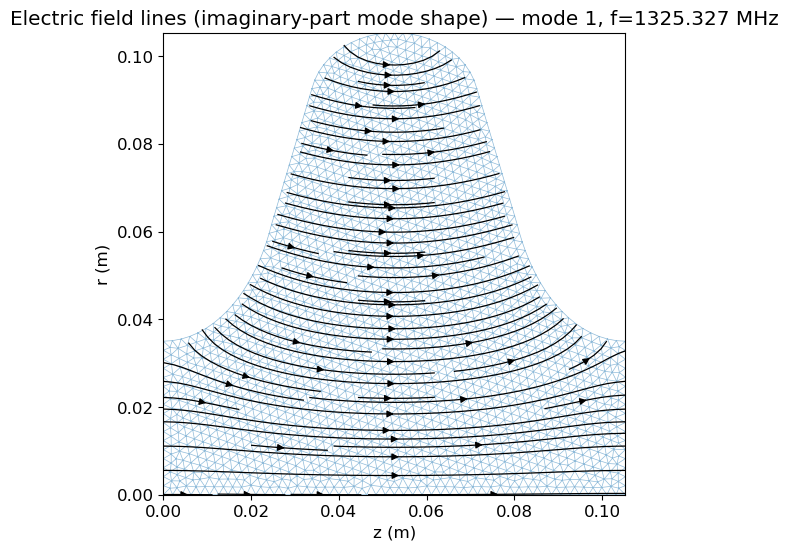

In [15]:
# Cell 8 - compute gradients, reconstruct E fields, and plot field lines
if 'H_full' not in globals():
    raise RuntimeError('Run Cell 8 first so H_full is available.')

# Compute nodal gradients from the selected H_phi mode.
n_tri = cells.shape[0]
tri_gradH = np.zeros((n_tri, 2), dtype=np.complex128)
for t_idx, tri in enumerate(cells):
    grads = tri_grads[t_idx]
    H_local = H_full[tri]
    tri_gradH[t_idx, :] = H_local @ grads

gradH_nodes = np.zeros((n_nodes, 2), dtype=np.complex128)
area_accum = np.zeros(n_nodes, dtype=float)
for t_idx, tri in enumerate(cells):
    a = tri_area[t_idx]
    for ni in tri:
        gradH_nodes[ni] += tri_gradH[t_idx] * a
        area_accum[ni] += a
nonzero = area_accum > 0
gradH_nodes[nonzero] /= area_accum[nonzero][:, None]
gradH_nodes[~nonzero] = 0.0

dH_dz = gradH_nodes[:, 0]
dH_dr = gradH_nodes[:, 1]

eps0 = 8.8541878128e-12
omega = 2*np.pi * freqs[mode_index]
prefactor = 1.0 / (1j * omega * eps0)

H_nodes = H_full
r_nodes = points[:, 1]
r_safe = np.maximum(r_nodes, 1e-12)

E_r_nodes = -prefactor * dH_dz
E_z_nodes =  prefactor * (dH_dr + H_nodes / r_safe)

Ez_plot = E_z_nodes.imag
Er_plot = E_r_nodes.imag

triang = Triangulation(points[:, 0], points[:, 1], cells)
nx = 300
ny = 300
z_min, z_max = points[:, 0].min(), points[:, 0].max()
r_min, r_max = points[:, 1].min(), points[:, 1].max()
z_grid = np.linspace(z_min, z_max, nx)
r_grid = np.linspace(r_min, r_max, ny)
Z, R = np.meshgrid(z_grid, r_grid)

finder = triang.get_trifinder()
tri_ids = finder(Z, R)
n_total = tri_ids.size
n_inside = np.count_nonzero(tri_ids != -1)
print(f'Grid points: total={n_total}, inside mesh={n_inside}, outside={n_total-n_inside}')
if n_inside == 0:
    raise RuntimeError('No grid points fall inside the triangulation hull. Reduce grid extent or refine mesh.')

interp_Ez = LinearTriInterpolator(triang, Ez_plot)
interp_Er = LinearTriInterpolator(triang, Er_plot)

Ez_grid = np.zeros_like(Z, dtype=float)
Er_grid = np.zeros_like(Z, dtype=float)
pts_x = Z[tri_ids != -1].ravel()
pts_y = R[tri_ids != -1].ravel()
vals_Ez = interp_Ez(pts_x, pts_y)
vals_Er = interp_Er(pts_x, pts_y)

def _to_float_arr(v):
    if hasattr(v, 'mask'):
        arr = np.array(v.filled(np.nan), dtype=float)
    else:
        arr = np.array(v, dtype=float)
    return arr

vals_Ez = _to_float_arr(vals_Ez)
vals_Er = _to_float_arr(vals_Er)
inside_idx_flat = np.flatnonzero(tri_ids.ravel() != -1)
Ez_grid_flat = Ez_grid.ravel()
Er_grid_flat = Er_grid.ravel()
Ez_grid_flat[inside_idx_flat] = vals_Ez
Er_grid_flat[inside_idx_flat] = vals_Er
Ez_grid = np.nan_to_num(Ez_grid_flat.reshape(Ez_grid.shape), nan=0.0)
Er_grid = np.nan_to_num(Er_grid_flat.reshape(Er_grid.shape), nan=0.0)

E_mag_inside = np.sqrt(Ez_grid[tri_ids != -1]**2 + Er_grid[tri_ids != -1]**2)
print(f'Inside field magnitude: min={E_mag_inside.min():.3e}, max={E_mag_inside.max():.3e}, mean={E_mag_inside.mean():.3e}')

scale_for_plot = 1.0
if E_mag_inside.max() < 1e-12:
    scale_for_plot = 1e12
    print('Fields very small; scaling by', scale_for_plot, 'for visibility.')
Ez_plot_grid = Ez_grid * scale_for_plot
Er_plot_grid = Er_grid * scale_for_plot

seed_nx = 20
seed_ny = 20
seed_z = np.linspace(z_min + 1e-6, z_max - 1e-6, seed_nx)
seed_r = np.linspace(r_min + 1e-6, r_max - 1e-6, seed_ny)
SZ, SR = np.meshgrid(seed_z, seed_r)
seed_tri_ids = finder(SZ, SR)
seed_points = np.column_stack((SZ[seed_tri_ids != -1].ravel(), SR[seed_tri_ids != -1].ravel()))
print(f'Seeding {seed_points.shape[0]} streamlines (inside mesh).')

plt.figure(figsize=(8, 6))
plt.triplot(points[:, 0], points[:, 1], cells, lw=0.5, alpha=0.5)
plt.gca().set_aspect('equal')
plt.streamplot(
    z_grid,
    r_grid,
    Ez_plot_grid,
    Er_plot_grid,
    density=1.6,
    linewidth=0.9,
    arrowsize=1.0,
    color='black',
    start_points=seed_points if seed_points.size > 0 else None
)
plt.title(f'Electric field lines (imaginary-part mode shape) — mode {mode_index+1}, f={freqs[mode_index]/1e6:.3f} MHz')
plt.xlabel('z (m)')
plt.ylabel('r (m)')
plt.gca().set_aspect('equal')
plt.xlim(z_min, z_max)
plt.ylim(r_min, r_max)
plt.show()


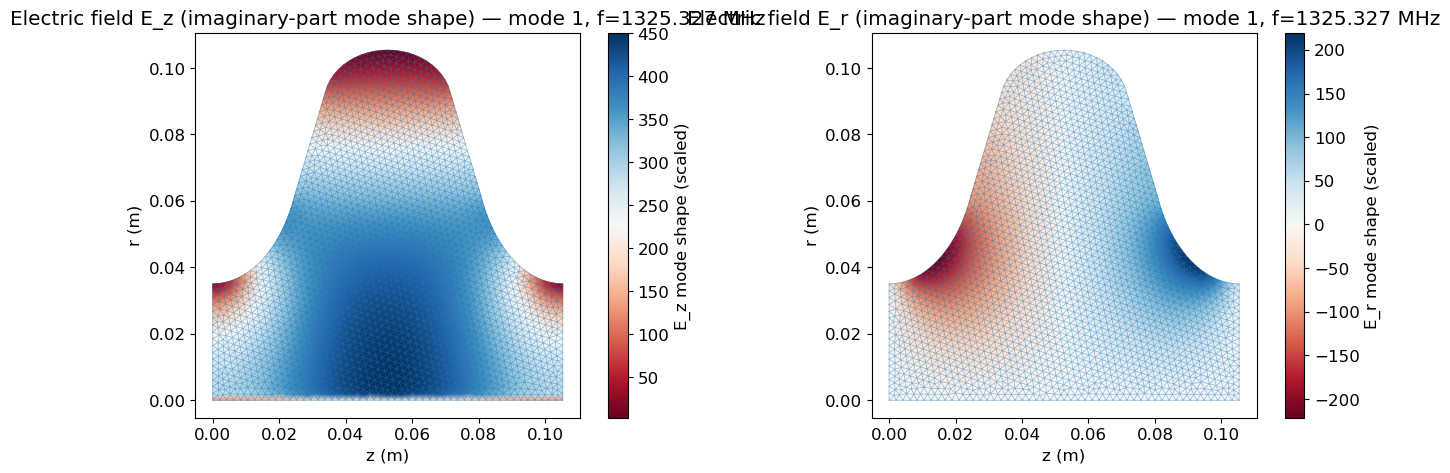

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
tpc_z = ax1.tripcolor(points[:,0], points[:,1], cells, Ez_plot, shading='gouraud', cmap='RdBu')
tpc_r = ax2.tripcolor(points[:,0], points[:,1], cells, Er_plot, shading='gouraud', cmap='RdBu')
plt.colorbar(tpc_z, label='E_z mode shape (scaled)')
plt.colorbar(tpc_r, label='E_r mode shape (scaled)')
ax1.triplot(points[:,0], points[:,1], cells, lw=0.5, alpha=0.5)
ax1.set_aspect('equal')
ax1.set_title(f"Electric field E_z (imaginary-part mode shape) — mode {mode_index+1}, f={freqs[mode_index]/1e6:.3f} MHz")
ax1.set_xlabel('z (m)')
ax1.set_ylabel('r (m)')
ax2.triplot(points[:,0], points[:,1], cells, lw=0.5, alpha=0.5)
ax2.set_aspect('equal')
ax2.set_title(f"Electric field E_r (imaginary-part mode shape) — mode {mode_index+1}, f={freqs[mode_index]/1e6:.3f} MHz")
ax2.set_xlabel('z (m)')
ax2.set_ylabel('r (m)')
plt.show()


Inside H-grad magnitude: min=3.715e-02, max=1.964e+01, mean=1.139e+01
Inside H-grad magnitude: min=3.715e-02, max=1.964e+01, mean=1.139e+01


<Figure size 800x600 with 0 Axes>

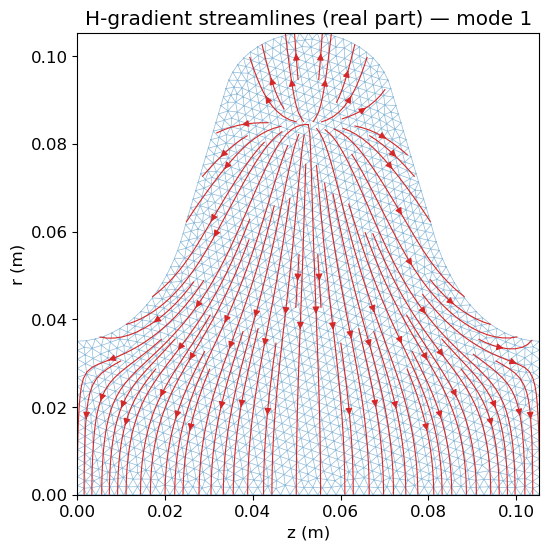

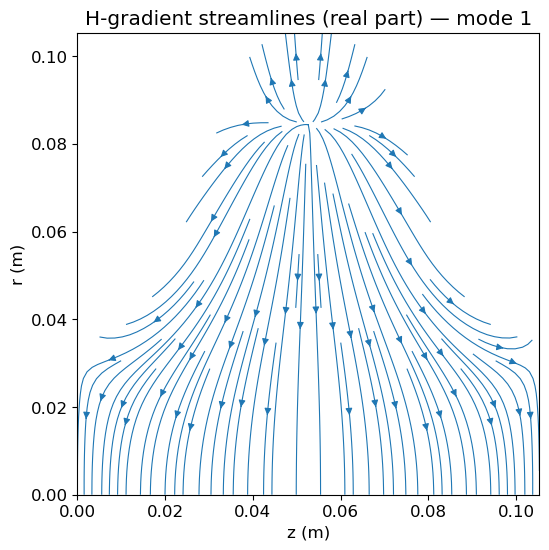

In [12]:
# --- Additional: plot streamlines for H-gradient (use grad H = [dH/dz, dH/dr]) ---
# Interpolate nodal gradients dH_dz, dH_dr (already computed in Cell 7) onto same grid
interp_dHdz = LinearTriInterpolator(triang, dH_dz.real)
interp_dHdr = LinearTriInterpolator(triang, dH_dr.real)

HZ_grid = np.zeros_like(Z, dtype=float)
HR_grid = np.zeros_like(Z, dtype=float)

vals_dHdz = interp_dHdz(pts_x, pts_y)
vals_dHdr = interp_dHdr(pts_x, pts_y)

vals_dHdz = _to_float_arr(vals_dHdz)
vals_dHdr = _to_float_arr(vals_dHdr)

HZ_grid_flat = HZ_grid.ravel()
HR_grid_flat = HR_grid.ravel()
HZ_grid_flat[inside_idx_flat] = vals_dHdz
HR_grid_flat[inside_idx_flat] = vals_dHdr
HZ_grid = HZ_grid_flat.reshape(HZ_grid.shape)
HR_grid = HR_grid_flat.reshape(HR_grid.shape)

# Replace NaNs
HZ_grid = np.nan_to_num(HZ_grid, nan=0.0)
HR_grid = np.nan_to_num(HR_grid, nan=0.0)

# Diagnostic for H-gradient magnitude
Hgrad_mag = np.sqrt(HZ_grid[tri_ids!=-1]**2 + HR_grid[tri_ids!=-1]**2)
print(f"Inside H-grad magnitude: min={Hgrad_mag.min():.3e}, max={Hgrad_mag.max():.3e}, mean={Hgrad_mag.mean():.3e}")

# Plot H-gradient streamlines (real part)
plt.figure(figsize=(8,6))
# --- Additional: plot streamlines for H-gradient (use grad H = [dH/dz, dH/dr]) ---
# Interpolate nodal gradients dH_dz, dH_dr (already computed in Cell 7) onto same grid
interp_dHdz = LinearTriInterpolator(triang, dH_dz.real)
interp_dHdr = LinearTriInterpolator(triang, dH_dr.real)

HZ_grid = np.zeros_like(Z, dtype=float)
HR_grid = np.zeros_like(Z, dtype=float)

vals_dHdz = interp_dHdz(pts_x, pts_y)
vals_dHdr = interp_dHdr(pts_x, pts_y)

vals_dHdz = _to_float_arr(vals_dHdz)
vals_dHdr = _to_float_arr(vals_dHdr)

HZ_grid_flat = HZ_grid.ravel()
HR_grid_flat = HR_grid.ravel()
HZ_grid_flat[inside_idx_flat] = vals_dHdz
HR_grid_flat[inside_idx_flat] = vals_dHdr
HZ_grid = HZ_grid_flat.reshape(HZ_grid.shape)
HR_grid = HR_grid_flat.reshape(HR_grid.shape)

# Replace NaNs
HZ_grid = np.nan_to_num(HZ_grid, nan=0.0)
HR_grid = np.nan_to_num(HR_grid, nan=0.0)

# Diagnostic for H-gradient magnitude
Hgrad_mag = np.sqrt(HZ_grid[tri_ids!=-1]**2 + HR_grid[tri_ids!=-1]**2)
print(f"Inside H-grad magnitude: min={Hgrad_mag.min():.3e}, max={Hgrad_mag.max():.3e}, mean={Hgrad_mag.mean():.3e}")

# Plot H-gradient streamlines (real part)
plt.figure(figsize=(8,6))
plt.triplot(points[:,0], points[:,1], cells, lw=0.5, alpha=0.5)
plt.gca().set_aspect('equal')
plt.streamplot(
    z_grid,
    r_grid,
    HZ_grid,    # U (x-direction) = dH/dz
    HR_grid,    # V (y-direction) = dH/dr
    density=2.0,
    linewidth=0.8,
    arrowsize=1.0,
    color='tab:red',
    start_points=seed_points if seed_points.size>0 else None
)
plt.title(f"H-gradient streamlines (real part) — mode {mode_index+1}")
plt.xlabel("z (m)")
plt.ylabel("r (m)")
plt.gca().set_aspect('equal')
plt.xlim(z_min, z_max)
plt.ylim(r_min, r_max)
plt.show()

plt.streamplot(
    z_grid,
    r_grid,
    HZ_grid,    # U (x-direction) = dH/dz
    HR_grid,    # V (y-direction) = dH/dr
    density=2.0,
    linewidth=0.8,
    arrowsize=1.0,
    color='tab:blue',
    start_points=seed_points if seed_points.size>0 else None
)
plt.title(f"H-gradient streamlines (real part) — mode {mode_index+1}")
plt.xlabel("z (m)")
plt.ylabel("r (m)")
plt.gca().set_aspect('equal')
plt.xlim(z_min, z_max)
plt.ylim(r_min, r_max)
plt.show()
